# Unidad 2 · Clase 3 — Correlación y Causalidad
## ¿Los datos mienten o nosotros los mal interpretamos?

**Pregunta central de la sesión:**
> *¿Cuánto tiempo en pantalla es demasiado? ¿Los datos pueden responderlo?*

**Dataset:** `digital_habits.csv` — 2,000 registros de hábitos digitales, sueño y bienestar

---

## Bloque 1 — Importaciones y carga del dataset

In [4]:
# Importa las librerías necesarias:
# pandas, numpy, matplotlib.pyplot, seaborn, scipy.stats
# Configura el estilo visual con plt.style.use('dark_background')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('dark_background')
sns.set_palette('coolwarm')

In [5]:
# Carga el archivo digital_habits.csv en un DataFrame llamado df
# Imprime el shape y muestra las primeras filas

# ── Carga ─────────────────────────────────────────────────────────────────────

df = pd.read_csv('digital_habits.csv')
print(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas")
df.head()


Dataset cargado: 2000 registros, 11 columnas


,Age,Gender,Occupation,Daily_Phone_Hours,Social_Media_Hours,Sleep_Hours,Stress_Level,Work_Productivity_Score,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,App_Usage_Count
0,35,Male,Manager,5.0,3.2,8.6,1.3,8.5,0.0,6.4,7
1,30,Male,Teacher,3.4,1.8,8.7,1.9,10.0,0.8,4.4,7
2,37,Male,Freelancer,6.9,3.9,6.5,2.8,8.4,0.7,10.5,9
3,44,Male,Student,1.9,0.5,7.8,1.0,9.8,0.3,4.8,9
4,30,Female,Student,6.3,3.4,7.7,1.0,9.7,0.0,8.5,11


## Bloque 2 — Primera correlación: pantalla vs sueño

**Hipótesis 1:** Más tiempo en pantalla → menos horas de sueño

Vamos a medirla con dos métodos: Pandas y scipy.stats.

In [6]:
# Calcula la correlación de Pearson entre 'Daily_Phone_Hours' y 'Sleep_Hours'
# Método 1: usando .corr() de Pandas
# Método 2: usando stats.pearsonr() — este también devuelve el p-value
# Imprime ambos resultados

r_pandas = df['Daily_Phone_Hours'].corr(df['Sleep_Hours'])
print(f"Pearson (Pandas):  r = {r_pandas:.3f}")

# Método 2: scipy — incluye p-value
r_scipy, p_value = stats.pearsonr(df['Daily_Phone_Hours'], df['Sleep_Hours'])
print(f"Pearson (scipy):   r = {r_scipy:.3f}  |  p-value = {p_value:.4f}")


Pearson (Pandas):  r = -0.423
Pearson (scipy):   r = -0.423  |  p-value = 0.0000


**Responde:** ¿El resultado confirma la hipótesis? ¿Qué significa que no sea r = -1.0?

*(Escribe tu interpretación aquí como comentario o celda Markdown)*

## Bloque 3 — El heatmap completo

In [ ]:
# Define la lista 'variables_numericas' con estas columnas:
# Daily_Phone_Hours, Social_Media_Hours, Sleep_Hours, Stress_Level,
# Work_Productivity_Score, Caffeine_Intake_Cups,
# Weekend_Screen_Time_Hours, App_Usage_Count

# Calcula la matriz de correlación con .corr()
# Guárdala en una variable llamada 'matriz_corr'


In [9]:
# Construye el heatmap con sns.heatmap()
# Usa: annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1
# Aplica mask para ocultar el triángulo superior (np.triu)
# Agrega un título descriptivo


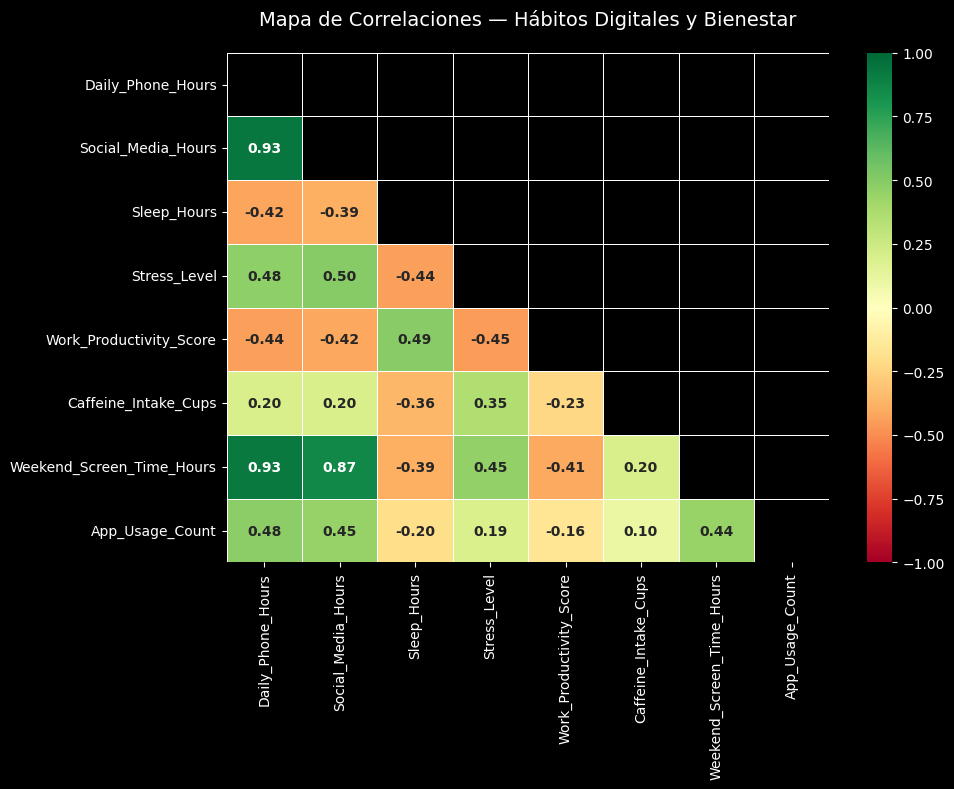

In [12]:
variables_numericas = [

    'Daily_Phone_Hours', 'Social_Media_Hours', 'Sleep_Hours',
    'Stress_Level', 'Work_Productivity_Score', 'Caffeine_Intake_Cups',
    'Weekend_Screen_Time_Hours', 'App_Usage_Count'
]

matriz_corr = df[variables_numericas].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(
    matriz_corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 10, 'weight': 'bold'}
)

ax.set_title('Mapa de Correlaciones — Hábitos Digitales y Bienestar', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**Momento de observación (60 segundos):**

Anota aquí la correlación que más te sorprendió y por qué:

## Bloque 4 — Ranking de correlaciones

In [10]:
# A partir de matriz_corr, extrae las correlaciones en formato lista
# Pasos:
# 1. .unstack() + .reset_index()
# 2. Renombra las columnas a: Variable_A, Variable_B, Correlacion
# 3. Filtra para eliminar la diagonal y duplicados
# 4. Crea columna 'Fuerza' con el valor absoluto
# 5. Ordena por Fuerza descendente y muestra el top 8
correlaciones = (
    matriz_corr
    .unstack()
    .reset_index()
    .rename(columns={'level_0': 'Variable_A', 'level_1': 'Variable_B', 0: 'Correlacion'})
)

correlaciones = correlaciones[correlaciones['Variable_A'] < correlaciones['Variable_B']]
correlaciones['Fuerza'] = correlaciones['Correlacion'].abs()
top = correlaciones.sort_values('Fuerza', ascending=False).head(8).reset_index(drop=True)

print("=== Top 8 correlaciones ===")
print(top[['Variable_A', 'Variable_B', 'Correlacion']].to_string(index=False))

=== Top 8 correlaciones ===
        Variable_A                Variable_B  Correlacion
 Daily_Phone_Hours        Social_Media_Hours     0.934276
 Daily_Phone_Hours Weekend_Screen_Time_Hours     0.925819
Social_Media_Hours Weekend_Screen_Time_Hours     0.865861
Social_Media_Hours              Stress_Level     0.496553
       Sleep_Hours   Work_Productivity_Score     0.487308
   App_Usage_Count         Daily_Phone_Hours     0.483176
 Daily_Phone_Hours              Stress_Level     0.475738
      Stress_Level Weekend_Screen_Time_Hours     0.454600


## Bloque 5 — Análisis multivariante

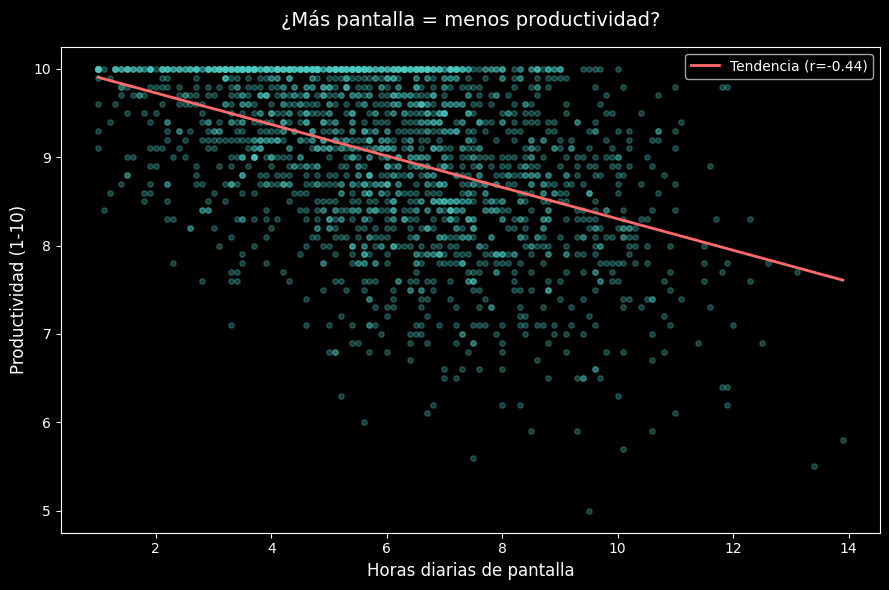

In [11]:
# Scatter plot: Daily_Phone_Hours vs Work_Productivity_Score
# Agrega una línea de tendencia con np.polyfit()
# Usa alpha=0.3, s=15 para los puntos
# Incluye el valor de r en la leyenda
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['Daily_Phone_Hours'], df['Work_Productivity_Score'],
           alpha=0.3, s=15, color='#4ecdc4')

m, b = np.polyfit(df['Daily_Phone_Hours'], df['Work_Productivity_Score'], 1)
x_line = np.linspace(df['Daily_Phone_Hours'].min(), df['Daily_Phone_Hours'].max(), 100)
r_val = df['Daily_Phone_Hours'].corr(df['Work_Productivity_Score'])
ax.plot(x_line, m*x_line + b, color='#ff6b6b', linewidth=2, label=f'Tendencia (r={r_val:.2f})')
ax.set_xlabel('Horas diarias de pantalla', fontsize=12)
ax.set_ylabel('Productividad (1-10)', fontsize=12)
ax.set_title('¿Más pantalla = menos productividad?', fontsize=14, pad=15)
ax.legend()
plt.tight_layout()
plt.show()

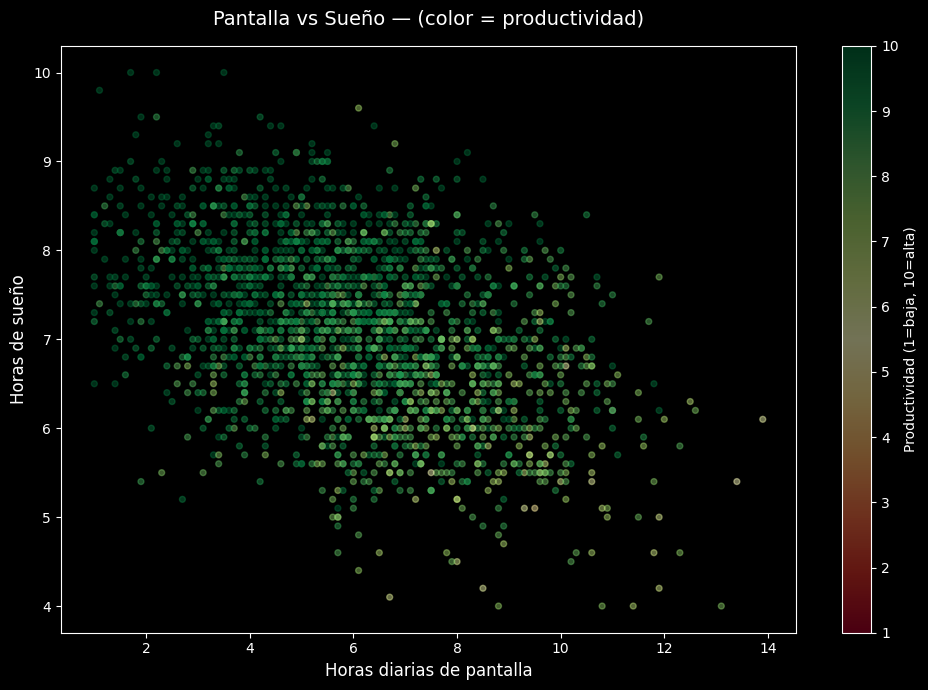

In [13]:
# Scatter multivariante: Daily_Phone_Hours vs Sleep_Hours
# La tercera variable: Stress_Level como color (parámetro c=)
# Usa cmap='RdYlGn_r' — rojo=alto estrés, verde=bajo estrés
# Agrega colorbar con plt.colorbar()
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df['Daily_Phone_Hours'], df['Sleep_Hours'],
    c=df['Work_Productivity_Score'], cmap='RdYlGn',
    alpha=0.45, s=18, vmin=1, vmax=10
)

plt.colorbar(scatter, label='Productividad (1=baja, 10=alta)')
ax.set_xlabel('Horas diarias de pantalla', fontsize=12)
ax.set_ylabel('Horas de sueño', fontsize=12)
ax.set_title('Pantalla vs Sueño — (color = productividad)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [16]:
print("Correlación: Pantalla diaria  Estrés — por ocupación\n")
print(f"{'Ocupación':<15} {'r de Pearson':>14} {'n':>6}")
print("-" * 38)

for ocupacion, grupo in df.groupby('Occupation'):
    r, p = stats.pearsonr(
        grupo['Daily_Phone_Hours'],
        grupo['Stress_Level']
    )

    print(f"{ocupacion:<15} {r:>14.3f} {len(grupo):>6}")

Correlación: Pantalla diaria  Estrés — por ocupación

Ocupación         r de Pearson      n
--------------------------------------
Designer                 0.414    265
Engineer                 0.536    445
Freelancer               0.421    309
Manager                  0.492    337
Student                  0.497    408
Teacher                  0.440    236


In [ ]:
# Correlación segmentada por ocupación
# Para cada grupo en df.groupby('Occupation'):
#   calcula stats.pearsonr entre Daily_Phone_Hours y Stress_Level
#   imprime: ocupación, r, y n del grupo


**Pregunta de análisis:**

Los ingenieros tienen la correlación más alta entre pantalla y estrés.
¿Eso significa que son más vulnerables al estrés digital, o hay otra explicación?

## Bloque 6 — Correlación vs Causalidad

**r = 0.50 entre redes sociales y estrés.**

Responde en esta celda:

1. ¿Las redes sociales *causan* estrés? ¿Cómo lo sabrías?
2. ¿Qué es una variable confusora? Da un ejemplo del dataset.
3. Si fueras analista de bienestar en una empresa, ¿qué decisión tomarías con este número?

## Bloque 7 — Pregunta puente a Clase 4

In [ ]:
# Observa esta correlación:
r_redundancia = df['Daily_Phone_Hours'].corr(df['Social_Media_Hours'])
print(f"Daily_Phone_Hours <-> Social_Media_Hours: r = {r_redundancia:.3f}")

# Pregunta para reflexionar:
# Si quisiéramos predecir Work_Productivity_Score con un modelo de ML,
# ¿incluirías ambas variables? ¿Qué problema podría generar?
# (Escribe tu respuesta como comentario)


---
*© 2026 Ana Alvarado · Educadora Tech & Desarrolladora Full Stack · Todos los derechos reservados · linkedin.com/in/ana-alvarado-instructora-full-stack*